### *Observação: Em muitas das células, as últimas linhas destinadas a visualização foram comentadas afim de diminuir o tempo de processamento do código*

__LIMPEZA INICIAL DOS DADOS__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)  # Exibe todas as colunas


# 1. Carregar as tabelas necessárias
admissions = pd.read_csv('admissions.csv', 
                         usecols=['subject_id', 'admittime', 'dischtime', 'hospital_expire_flag'])

chartevents = pd.read_csv('chartevents.csv', 
                          low_memory= False, 
                          usecols=['subject_id', 'itemid', 'charttime', 'value'])

icustays = pd.read_csv('icustays.csv', usecols=['subject_id', 'los'])

patients = pd.read_csv('patients.csv', usecols=['subject_id', 'dob', 'gender'])

d_items = pd.read_csv('d_items.csv', usecols=['itemid', 'label'])


# 2. Retirar sinais vitais categóricos, renomear coluna 'los' para 'los_icu', e binarizar gênero do paciente
admissions = admissions.dropna(subset='hospital_expire_flag')

chartevents['value'] = pd.to_numeric(chartevents['value'], errors='coerce')
chartevents = chartevents.dropna(subset=['value'])

icustays = icustays.rename(columns={'los': 'los_icu'})


# 3. Exclusão dos pacientes que tiveram sua dob anonimizada e binzarização do gênero
patients['dob'] = pd.to_datetime(patients['dob'])
patients = patients[patients['dob'].dt.year > 2000]

patients['gender'] = patients['gender'].map({'M': [1, 0], 'F': [0, 1]})
patients = patients.dropna(subset='gender')


## 4. Usar os 5 sinais principais.
sinais_target = dict(
itemid_51 = 'Arterial BP [Systolic]',
itemid_8368 = 'Arterial BP [Diastolic]',
itemid_220050 = 'Arterial Blood Pressure systolic',
itemid_220051 = 'Arterial Blood Pressure diastolic',
itemid_220179 = 'Non Invasive Blood Pressure systolic',     # fazer value < 10000
itemid_220180 = 'Non Invasive Blood Pressure diastolic',
#itemid_225309 = 'ART BP Systolic',
#itemid_225310 = 'ART BP Diastolic',

itemid_211 = 'Heart Rate (carevue)',
itemid_220045 = 'Heart Rate (MetaVision)',

itemid_676 = 'Temperature C',
itemid_677 = 'Temperature C (calc)',

itemid_618 = 'Respiratory Rate (carevue)',
#itemid_619 = 'Respiratory Rate Set (carevue)',
itemid_220210 = 'Respiratory Rate (MetaVision)',
#itemid_224688 = 'Respiratory Rate (Set) (MetaVision)',            #Total é a soma desses dois
#itemid_224689 = 'Respiratory Rate (spontaneous)',                 #Total é a soma desses dois
#itemid_224690= 'Respiratory Rate (Total)',

itemid_646 = 'SpO2',
#itemid_490 = 'PAO2',
#itemid_779 = 'Arterial PaO2',
itemid_834 = 'SaO2',
itemid_220277 = 'O2 saturation pulse oxymetry',
itemid_220227 = 'Arterial O2 Saturation'
)

sinais_target_num = {int(key.split('_')[-1]): value for key, value in sinais_target.items()}


itemids = list(sinais_target.keys()) 
itemids_num = list(sinais_target_num.keys())
labels = list(sinais_target.values())

d_items = d_items[d_items['label'].isin(labels)]


# Considerar usar 'Weight (kg)'
filters = {
    'Arterial BP [Systolic]': (20, None),
    'Arterial BP [Diastolic]': (10, 130),
    'Arterial Blood Pressure systolic': (20, 220),
    'Arterial Blood Pressure diastolic': (10, 120),
    'Non Invasive Blood Pressure systolic': (20, 220),
    'Non Invasive Blood Pressure diastolic': (None, 120),
    'Heart Rate (carevue)': (30, None),
    'Heart Rate (MetaVision)': (30, None),
    'Respiratory Rate (carevue)': (None, 60),
    'Respiratory Rate (MetaVision)': (None, 60),
    'Temperature C': (None, None),
    'Temperature C (calc)': (None, None),
    'SpO2': (None, None),
    'SaO2': (None, None),
    'O2 saturation pulse oxymetry': (None, None),
    'Arterial O2 Saturation': (None, None)
}

def df_filter(df):
    dfs_filtrados = []  # Lista para armazenar DataFrames filtrados

    # Iterar sobre cada itemid e seus limites no dicionário de filtros
    for label, (min_val, max_val) in filters.items():
        # Filtrar apenas as linhas correspondentes ao itemid atual
        df_item = df[df[label] == True]  # Isola as linhas do itemid atual

        # Aplicar o filtro mínimo, se necessário
        if min_val is not None:
            df_item = df_item[df_item['value'] > min_val]

        # Aplicar o filtro máximo, se necessário
        if max_val is not None:
            df_item = df_item[df_item['value'] < max_val]

        # Adicionar o DataFrame filtrado à lista
        dfs_filtrados.append(df_item)

    # Concatenar todos os DataFrames filtrados em um só
    df_final = pd.concat(dfs_filtrados, ignore_index=True)
    return df_final

def df_filter2(df):
    dfs_filtrados = []  # Lista para armazenar DataFrames filtrados

    # Iterar sobre cada itemid e seus limites no dicionário de filtros
    for label, (min_val, max_val) in filters.items():
        # Filtrar apenas as linhas correspondentes ao itemid atual
        df_item = df[df['label'] == label]  # Isola as linhas do itemid atual

        # Aplicar o filtro mínimo, se necessário
        if min_val is not None:
            df_item = df_item[df_item['value'] > min_val]

        # Aplicar o filtro máximo, se necessário
        if max_val is not None:
            df_item = df_item[df_item['value'] < max_val]

        # Adicionar o DataFrame filtrado à lista
        dfs_filtrados.append(df_item)

    # Concatenar todos os DataFrames filtrados em um só
    df_final = pd.concat(dfs_filtrados, ignore_index=True)
    return df_final

__VISUALIZAÇÃO INICIAL__


Contagem de Desfechos Clínicos Adversos

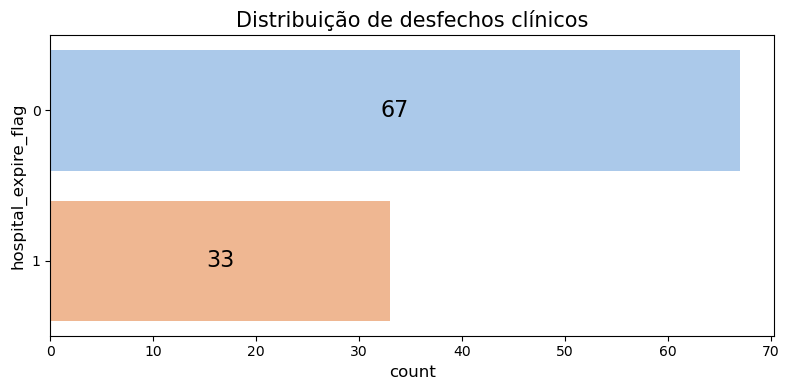

In [2]:
df_count = admissions.drop_duplicates(subset='subject_id')

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_count, y='hospital_expire_flag', palette='pastel')

# Adicionar os números maiores e centralizados nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}', 
                (p.get_width() / 2, p.get_y() + p.get_height() / 2),  # Centralizar
                ha='center', va='center',  # Alinhar centralmente
                fontsize=16,   color='black')  # Aumentar o tamanho

# Ajustar título e layout
plt.title('Distribuição de desfechos clínicos', fontsize=15)
plt.xlabel('count', fontsize=12)
plt.ylabel('hospital_expire_flag', fontsize=12)

plt.tight_layout()
plt.savefig('Distribuição de Desfechos Clínicos.png', dpi=1000, bbox_inches='tight')
plt.show()

LINECHART

Sinais vitais isoladamente para um paciente

In [3]:
# Filtrar por subject_id e múltiplos itemid
subject_id_alvo = 40595

df_filtrado_subject_id = chartevents[(chartevents['subject_id'] == subject_id_alvo)]

# Ordenar por 'charttime'
df_filtrado_subject_id = df_filtrado_subject_id.sort_values(by='charttime')

# Criar colunas binárias usando get_dummies para itemid
df_dummies = pd.get_dummies(df_filtrado_subject_id['itemid'], prefix='itemid')

cols_encontradas = [col for col in itemids if col in df_dummies.columns]

df_dummies = df_dummies[cols_encontradas]



# Combinar df.dummies com 'charttime' e 'value'
df_filtrado_subject_id = pd.concat([df_filtrado_subject_id[['charttime', 'value']], df_dummies], axis=1)

df_filtrado_subject_id = df_filtrado_subject_id.rename(columns=sinais_target)

In [4]:
def lineplot_by_subject_id(df,lista):

    for itemid in lista:
        
        try: 
            df_itemid = df[df[itemid] == True][['charttime', 'value']]

            plt.figure(figsize=(20, 6))
            sns.lineplot(x='charttime', y='value', data= df_itemid)
            plt.xticks(rotation=90)
            plt.title(f"Valores ao Longo do Tempo - {itemid}")
            plt.show()
        except: 
            None

itemids_para_plotar = labels

#lineplot_by_subject_id(df_filtrado_subject_id, itemids_para_plotar)

Múltiplos Pacientes Simultaneamente para cada sinal vital

In [5]:
df_dummies = pd.get_dummies(chartevents['itemid'], prefix='itemid')

cols_encontradas = [col for col in itemids if col in df_dummies.columns]

df_dummies = df_dummies[cols_encontradas]

# Combinar df.dummies com 'charttime' e 'value'
df_filtrado_itemid = pd.concat([chartevents[['subject_id', 'charttime', 'value']], df_dummies], axis=1)

df_filtrado_itemid = df_filtrado_itemid.rename(columns=sinais_target)

In [6]:
def scatterplot_multiple_subject_id(df, itemids_selecionados):
    for itemid in itemids_selecionados:
        df_itemid = df[(df[itemid] == True)]
        df_itemid = df_itemid.sort_values(by='charttime')

        df_itemid = df_filter(df_itemid)

        palette = sns.color_palette('viridis')
        plt.figure(figsize=(15, 11)) 
        sns.scatterplot(
            data=df_itemid, 
            x='charttime', 
            y='value', 
            hue='subject_id',
            palette=palette
        )
        
        # Ajustar rótulos e formatação
        plt.title(f'Valores ao Longo do Tempo - {itemid}', fontsize=16)
        plt.xlabel('Tempo (charttime)', fontsize=14)
        plt.ylabel('Valor (value)', fontsize=14)
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(50))  # Exibe no máximo n ticks
        plt.xticks(rotation=90)
        plt.legend(title='subject_id', loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
        
        plt.tight_layout()
        #plt.savefig(f'scatterplot sem tratar {itemid}.png', dpi=300, bbox_inches='tight')
        plt.show()

#scatterplot_multiple_subject_id(df_filtrado_itemid, labels)

In [7]:
def lineplot_multiple_subject_id(df, itemids_selecionados):
    for itemid in itemids_selecionados:
        df_itemid = df[(df[itemid] == True)]
        df_itemid = df_itemid.sort_values(by='charttime')

        df_itemid = df_filter(df_itemid)

        plt.figure(figsize=(15, 8))  # Nova figura para cada itemid
        sns.lineplot(
            data=df_itemid, 
            x='charttime', 
            y='value', 
            hue='subject_id',
            palette='flare'
        )
        
        # Ajustar rótulos e formatação
        plt.title(f'Valores ao Longo do Tempo - {itemid}', fontsize=16)
        plt.xlabel('Tempo (charttime)', fontsize=14)
        plt.ylabel('Valor (value)', fontsize=14)
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(50))  # Exibe no máximo n ticks
        plt.xticks(rotation=90)
        plt.legend(title='subject_id', loc='upper left')
        
        plt.tight_layout()
        #plt.savefig(f'lineplot sem tratar {itemid}.png', dpi=300, bbox_inches='tight')
        plt.show()

#lineplot_multiple_subject_id(df_filtrado_itemid, labels)

BOXPLOT

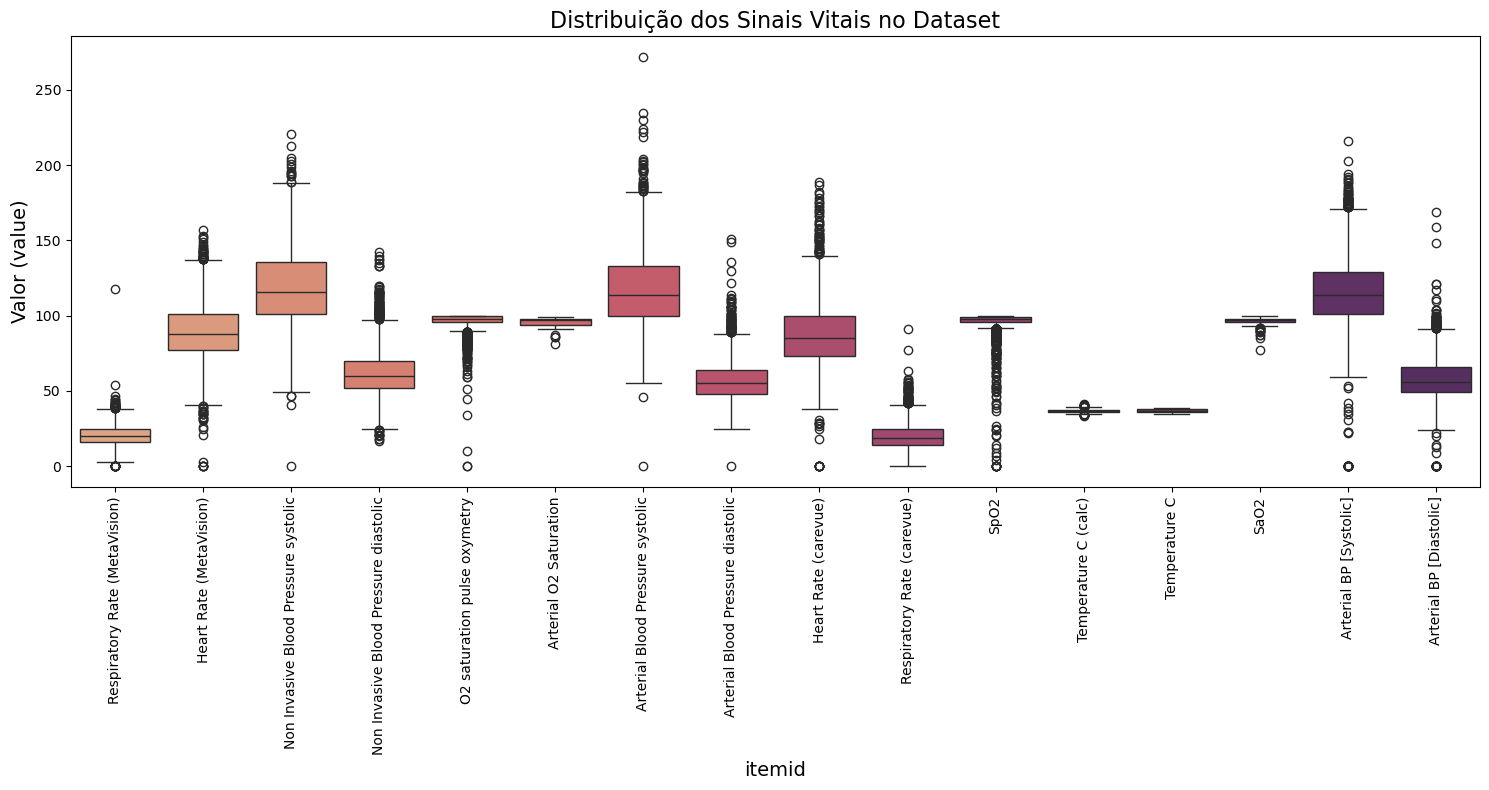

In [8]:
def boxplot_multiple_subject_id(df):
    df = df[df['itemid'].isin(itemids_num)]
    df['itemid'] = df['itemid'].replace(sinais_target_num)
    df = df[df['value'] < 10000 ]

    plt.figure(figsize=(15, 8))
    sns.boxplot(
        data=df, 
        x='itemid', 
        y='value', 
        hue='itemid',
        palette='flare'
    )
    
    # Ajustar rótulos e formatação
    plt.title(f'Distribuição dos Sinais Vitais no Dataset', fontsize=16)
    plt.xlabel('itemid', fontsize=14)
    plt.ylabel('Valor (value)', fontsize=14)
    plt.xticks(rotation=90)
    
    plt.tight_layout()
    #plt.savefig('boxplot tratado.png', dpi=300, bbox_inches='tight')
    plt.show()

boxplot_multiple_subject_id(chartevents)

TRATAMENTO DOS DADOS

In [9]:
# 3. Fazer o merge das tabelas principais
merged_data = pd.merge(admissions,   patients,        on='subject_id',  how='left')
merged_data = pd.merge(merged_data,  icustays,        on='subject_id',  how='left')
merged_data = pd.merge(merged_data,  chartevents,     on='subject_id',  how='inner')
merged_data = pd.merge(merged_data,  d_items,         on='itemid',      how='inner')


# 4. Converter colunas de datas para datetime
merged_data['dischtime'] = pd.to_datetime(merged_data['dischtime'])
merged_data['admittime'] = pd.to_datetime(merged_data['admittime'])
merged_data['charttime'] = pd.to_datetime(merged_data['charttime'])


# Cálculo da idade
merged_data['idade'] = (merged_data['admittime'] - merged_data['dob']).dt.days / 365.25

# 6. Calcular los_hosp como a diferença entre dischtime e admittime (em dias)
merged_data['los_hosp'] = (merged_data['dischtime'] - merged_data['admittime']).dt.total_seconds() / 86400

# 7. Contar o número de internações hospitalares e na UTI por paciente
num_admissions_hosp = admissions.groupby('subject_id').size().reset_index(name='num_admissions_hosp')
num_admissions_icu = icustays.groupby('subject_id').size().reset_index(name='num_admissions_icu')

# 8. Adicionar as contagens de internações ao dataset
merged_data = pd.merge(merged_data, num_admissions_hosp, on='subject_id', how='left')
merged_data = pd.merge(merged_data, num_admissions_icu, on='subject_id', how='left')


merged_data = merged_data.drop(columns= ['admittime','dischtime','dob'])
merged_data = merged_data.dropna(subset='idade')

reduced_data = merged_data[
    ['subject_id', 'gender', 'los_icu', 
     'los_hosp', 'idade', 'num_admissions_hosp', 
     'num_admissions_icu', 'hospital_expire_flag']]
reduced_data = reduced_data.drop_duplicates(subset=['subject_id'])

In [10]:
#merged_data

Scatter plot com regressão (n extraímos nada)

In [37]:
df_lmplot = merged_data[
    ['subject_id','los_hosp','los_icu','idade','num_admissions_hosp', 'num_admissions_icu','hospital_expire_flag']]
df_lmplot = df_lmplot.drop_duplicates('subject_id')

df_lmplot = df_lmplot[df_lmplot['num_admissions_hosp'] < 10]
df_lmplot = df_lmplot[(df_lmplot['los_hosp'] < 60)]

In [12]:
def lmplot(df,x,y):
    sns.lmplot(x=x, y=y, data=df, height= 6, aspect=1.5, hue='hospital_expire_flag')
    plt.title("Idade do paciente em função da QTD. de dias internado", fontsize = 14)
    plt.show()

#lmplot(df_lmplot,'num_admissions_hosp','idade')
#lmplot(df_lmplot,'los_hosp','idade')
#lmplot(df_lmplot,'los_icu','idade')

Facetgrid (n conseguimos ajustar as cores)

In [13]:
def facetgrid_sinais_com_janelas(df, label):
    # Filtrar apenas os dados do sinal vital específico
    df_filtrado = df[df['label'] == label].copy()

    # Verificar se 'charttime' está no formato datetime, caso contrário, converter
    if not pd.api.types.is_datetime64_any_dtype(df_filtrado['charttime']):
        df_filtrado['charttime'] = pd.to_datetime(df_filtrado['charttime'], errors='coerce')

    # Remover valores NaT (caso a conversão para datetime tenha falhado)
    df_filtrado = df_filtrado.dropna(subset=['charttime'])

    # Ordenar por 'charttime' para garantir sequência cronológica
    df_filtrado = df_filtrado.sort_values(by='charttime')

    # Garantir que a coluna 'hospital_expire_flag' esteja presente e não contenha listas ou dados incorretos
    if 'hospital_expire_flag' in df_filtrado.columns:
        df_filtrado['hospital_expire_flag'] = df_filtrado['hospital_expire_flag'].astype(str)

    # Criar o FacetGrid para visualização
    g = sns.FacetGrid(
        df_filtrado, col='subject_id', col_wrap=4, height=4, 
        sharex=False, sharey=True
    )

    # Adicionar scatterplot para cada gráfico da grade
    g.map_dataframe(
        sns.scatterplot, x='charttime', y='value', 
        hue='hospital_expire_flag', palette='coolwarm'
    )

    # Ajustar layout e adicionar título
    g.set_titles("{col_name}")  # Título de cada facet
    g.set_axis_labels('Tempo (charttime)', 'Valor (value)')

    # Ajustar a rotação dos rótulos do eixo X
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajuste para o título não sobrepor o layout
    plt.show()

#facetgrid_sinais_com_janelas(merged_data, 'SpO2')

HeatMap

In [14]:
# Agrupar os valores por sinais vitais e charttime
df_agg = df_filter2(merged_data)

df_agg = df_agg.groupby(['hospital_expire_flag', 'itemid'])['value'].mean().unstack()
df_agg = df_agg.rename(columns= sinais_target_num)

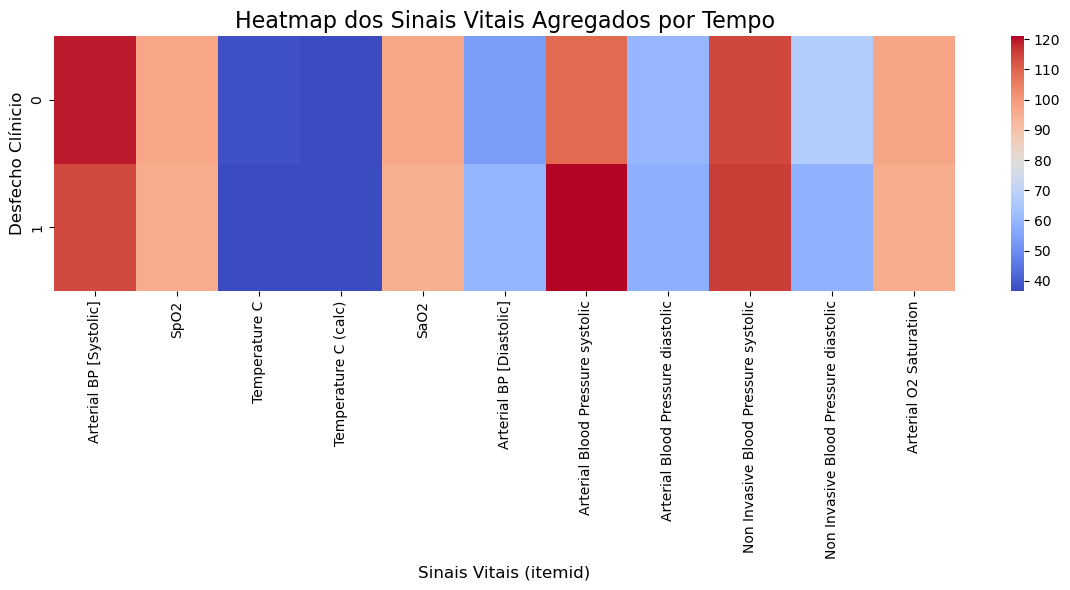

In [15]:
# Plotar o heatmap com os valores médios
plt.figure(figsize=(12, 6))
sns.heatmap(data=df_agg, cmap='coolwarm', annot=False, cbar=True)

plt.title('Heatmap dos Sinais Vitais Agregados por Tempo', fontsize=16)
plt.xlabel('Sinais Vitais (itemid)', fontsize=12)
plt.ylabel('Desfecho Clínicio', fontsize=12)

plt.tight_layout()
#plt.show()

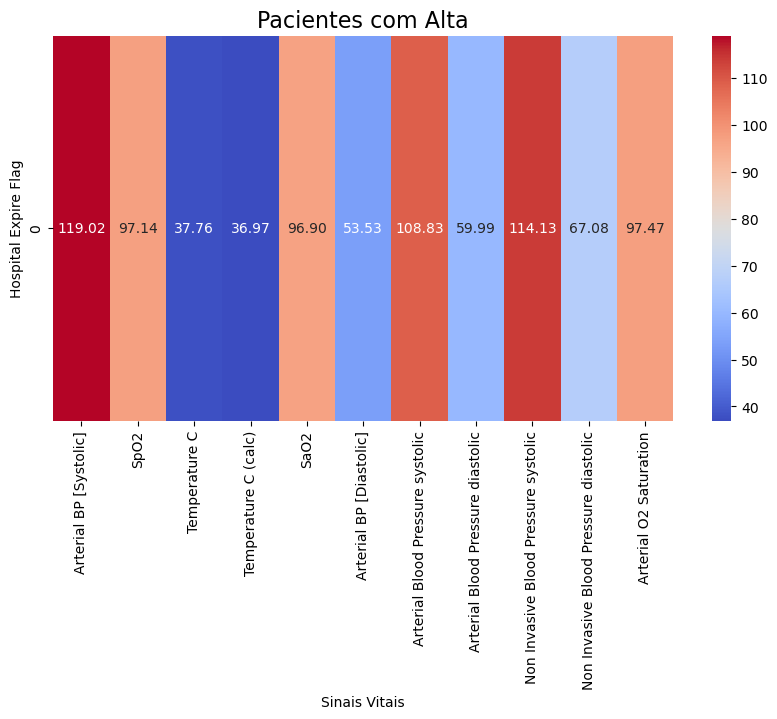

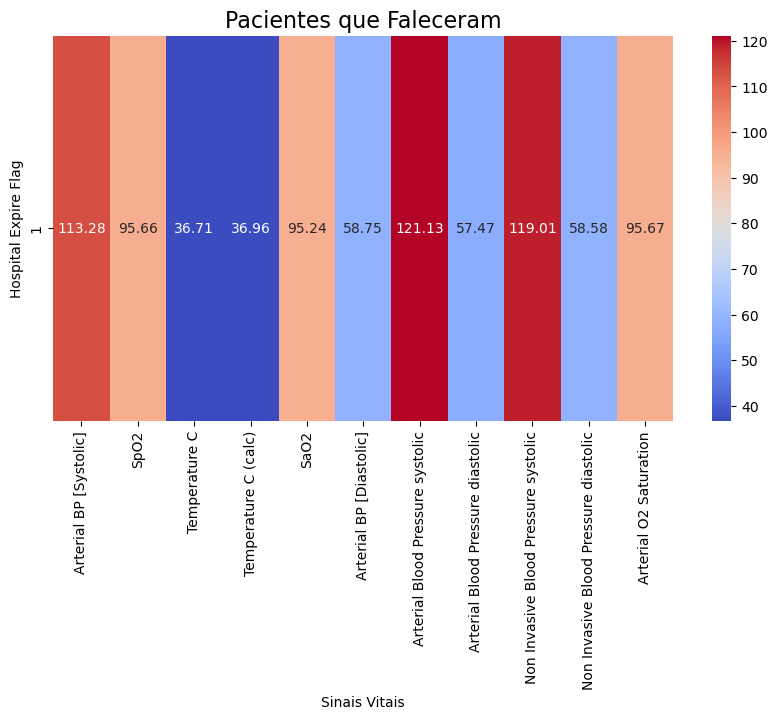

In [16]:
# Filtrar por alta e óbito
alta = merged_data[merged_data['hospital_expire_flag'] == 0]
obito = merged_data[merged_data['hospital_expire_flag'] == 1]

# Gerar heatmap para cada grupo
for df, title in [(alta, 'Pacientes com Alta'), (obito, 'Pacientes que Faleceram')]:
    df_agg = df.groupby(['hospital_expire_flag', 'itemid'])['value'].mean().unstack()

    # Renomear colunas para facilitar a leitura (caso necessário)
    df_agg = df_agg.rename(columns=sinais_target_num)

    # Plotar o heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(data=df_agg, cmap='coolwarm', annot=True, fmt='.2f')
    plt.title(title, fontsize=16)
    plt.xlabel('Sinais Vitais')
    plt.ylabel('Hospital Expire Flag')
    #plt.show()

__PREPARAÇÃO PARA O MODELO__

In [17]:
def dividir_charttimes_em_n_intervalos(df, n):
    """
    Divide os charttimes de cada subject_id em N intervalos iguais.
    """
    # Função auxiliar: cria intervalos para um grupo de um único subject_id
    def criar_intervalos(grupo):
        # Calcula os limites do tempo mínimo e máximo
        min_time = grupo['charttime'].min()
        max_time = grupo['charttime'].max()
        
        # Cria N intervalos de tempo igualmente espaçados
        intervalos = pd.date_range(start=min_time, end=max_time, periods=n + 1)
        
        # Atribui cada charttime a um intervalo correspondente
        grupo['time_window'] = pd.cut(
            grupo['charttime'], 
            bins=intervalos, 
            labels=[f'tempo {i} - tempo {i+1}' for i in range(n)],
            include_lowest=True
        )
        return grupo

    # Aplica a função para cada grupo de subject_id
    df = df.groupby('subject_id', group_keys=False).apply(criar_intervalos)
    return df

# Aplicando a função ao DataFrame merged_data
merged_data_com_intervalos = dividir_charttimes_em_n_intervalos(merged_data, n=5)


In [18]:
merged_data_com_intervalos = df_filter2(merged_data_com_intervalos)

In [19]:
# Pivotar: Cada itemid vira uma coluna separada
df_pivotado = merged_data_com_intervalos.pivot_table(
    index=['subject_id', 'time_window'], 
    columns='itemid', 
    values='value',
    aggfunc='mean'
)

# Adicionar prefixo 'itemid_' nas colunas para fácil identificação
df_pivotado.columns = [f'itemid_{int(col)}' for col in df_pivotado.columns]

# Resetar o índice para organizar a tabela final
#df_pivotado = df_pivotado.reset_index()

#df_pivotado = df_pivotado.set_index(['subject_id', 'time_window'])

df_pivotado = df_pivotado.rename(columns=sinais_target)

df_pivotado = df_pivotado.reset_index()

In [20]:
df_final = pd.merge(
    df_pivotado,  # Resetando o índice para ter subject_id como coluna
    admissions[['subject_id', 'hospital_expire_flag']], 
    on='subject_id', 
    how='inner'
)

Importação das Bibliotecas

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc)

from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
 
from xgboost import plot_importance
import shap
import numpy as np

Regressão Logística

In [22]:
# Separar as variáveis explicativas (X) e o alvo (y)
X = df_final.drop(['subject_id','time_window', 'hospital_expire_flag'], axis=1)  # Removemos subject_id e a variável alvo
y = df_final['hospital_expire_flag']

X = X.fillna(0)

# Dividir em treino e teste
X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Tamanho do Xtreino: {X_train_rl.shape}, Tamanho do Xteste: {X_test_rl.shape}')

Tamanho do Xtreino: (361, 11), Tamanho do Xteste: (156, 11)


In [23]:
# Inicializar e treinar o modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train_rl, y_train_rl)

# Fazer previsões
y_pred_rl = model.predict(X_test_rl)

# Avaliar o modelo
print(confusion_matrix(y_test_rl, y_pred_rl))
print(classification_report(y_test_rl, y_pred_rl))

# Calcular acurácia
accuracy_rl = accuracy_score(y_test_rl, y_pred_rl)
print(f"Acurácia Regressão Logística: {accuracy_rl:.2f}")

[[105   4]
 [ 32  15]]
              precision    recall  f1-score   support

           0       0.77      0.96      0.85       109
           1       0.79      0.32      0.45        47

    accuracy                           0.77       156
   macro avg       0.78      0.64      0.65       156
weighted avg       0.77      0.77      0.73       156

Acurácia Regressão Logística: 0.77


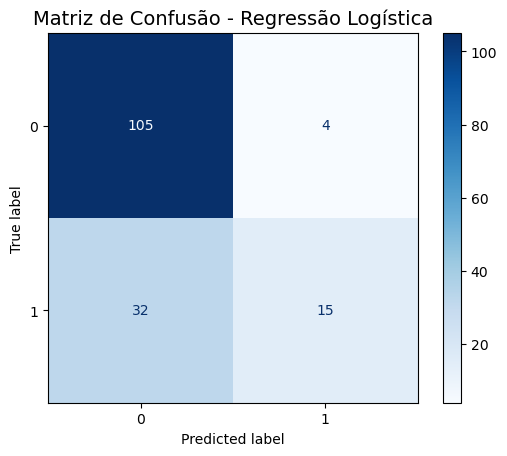

In [24]:
cm = confusion_matrix(y_test_rl, y_pred_rl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística', fontsize = 14)
plt.show()

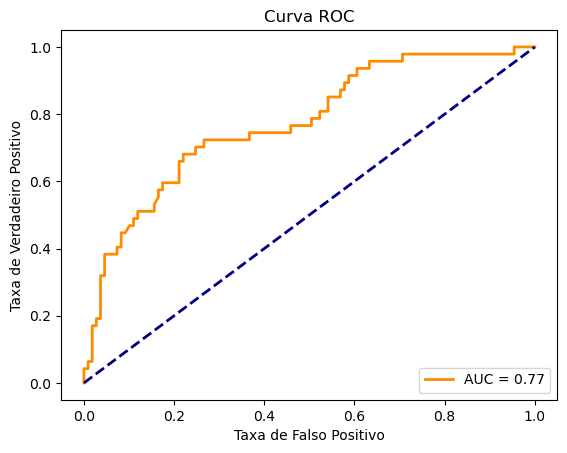

In [25]:
# Previsões probabilísticas para a classe positiva
y_prob = model.predict_proba(X_test_rl)[:, 1]

# Calcular ROC e AUC
fpr, tpr, _ = roc_curve(y_test_rl, y_prob)
roc_auc = auc(fpr, tpr)

# Plotar curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend(loc='lower right')
#plt.show()

Text(0.5, 1.0, 'Precision-Recall Curve')

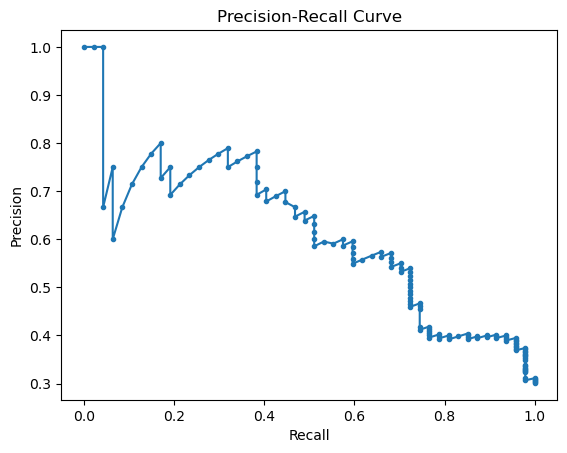

In [26]:
# Calcular precisão e recall
precision, recall, _ = precision_recall_curve(y_test_rl, y_prob)

# Plotar curva Precision-Recall
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
#plt.show()

_________

RandomForest

In [27]:
# Separar variáveis preditoras e alvo
X = df_final.drop(['subject_id','time_window', 'hospital_expire_flag'], axis=1)
y = df_final['hospital_expire_flag']

# Dividir os dados em treino e teste
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.3, random_state=42)

# Instanciar e treinar o modelo RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test_rf)

# Avaliação do modelo
print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))

accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"Acurácia Random Forest: {accuracy_rf:.2f}")

Confusion Matrix:
[[89 20]
 [24 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       109
           1       0.53      0.49      0.51        47

    accuracy                           0.72       156
   macro avg       0.66      0.65      0.66       156
weighted avg       0.71      0.72      0.71       156

Acurácia Random Forest: 0.72


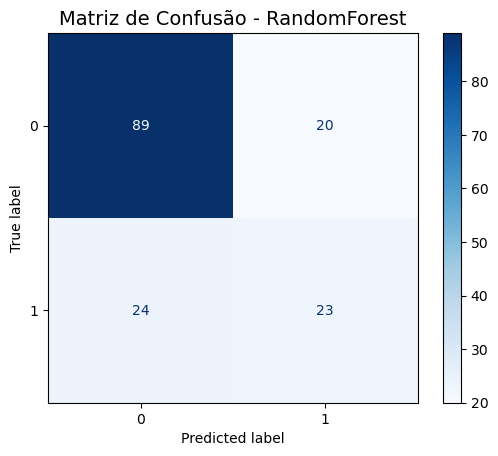

In [28]:
cm = confusion_matrix(y_test_rf, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - RandomForest', fontsize = 14)
plt.show()

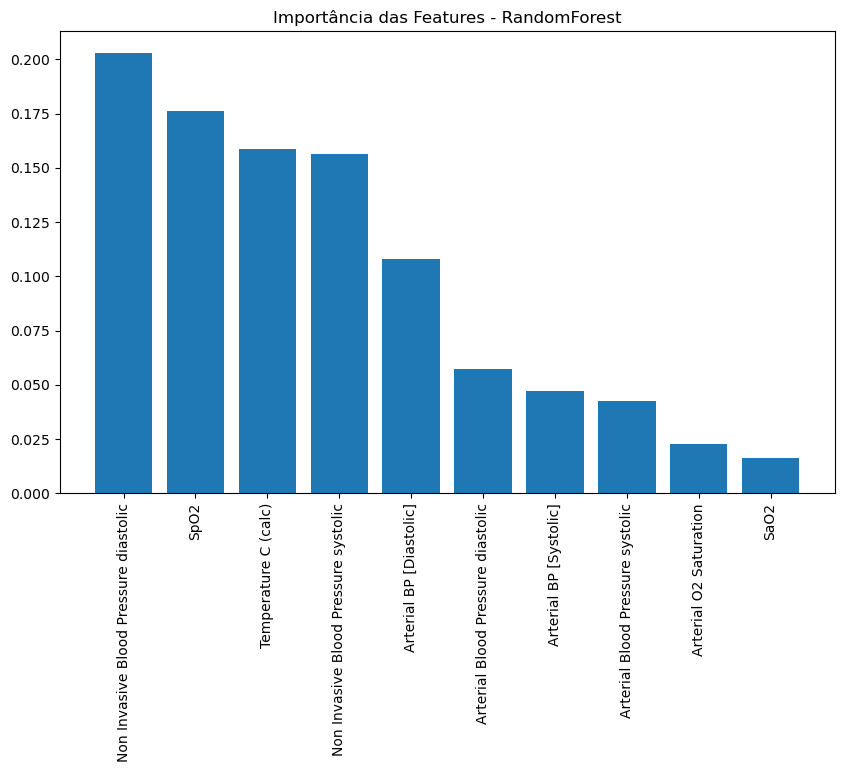

In [29]:
def plot_feature_importance(model, X_train, model_name):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title(f'Importância das Features - {model_name}')
    plt.bar(range(10), importances[indices[:10]], align='center')
    plt.xticks(range(10), X_train.columns[indices[:10]], rotation=90)
    plt.show()

plot_feature_importance(rf_model, X_train_rf, 'RandomForest')

____________

XGBoost

In [30]:
# Separar variáveis preditoras e alvo
X = df_final.drop(['subject_id','time_window', 'hospital_expire_flag'], axis=1)
y = df_final['hospital_expire_flag']

X.columns = X.columns.str.replace('[\[\]<>]', '', regex=True)

# Dividir os dados em treino e teste
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.3, random_state=42)

# Instanciar e treinar o modelo XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Previsões no conjunto de teste
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Avaliação do modelo
print("Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f"Acurácia XGBoost: {accuracy_xgb:.2f}")

Confusion Matrix:
[[88 21]
 [26 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       109
           1       0.50      0.45      0.47        47

    accuracy                           0.70       156
   macro avg       0.64      0.63      0.63       156
weighted avg       0.69      0.70      0.69       156

Acurácia XGBoost: 0.70


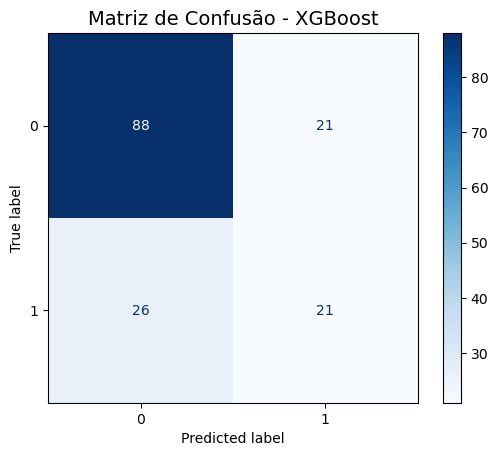

In [31]:
cm = confusion_matrix(y_test_xgb, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - XGBoost', fontsize = 14)
plt.show()

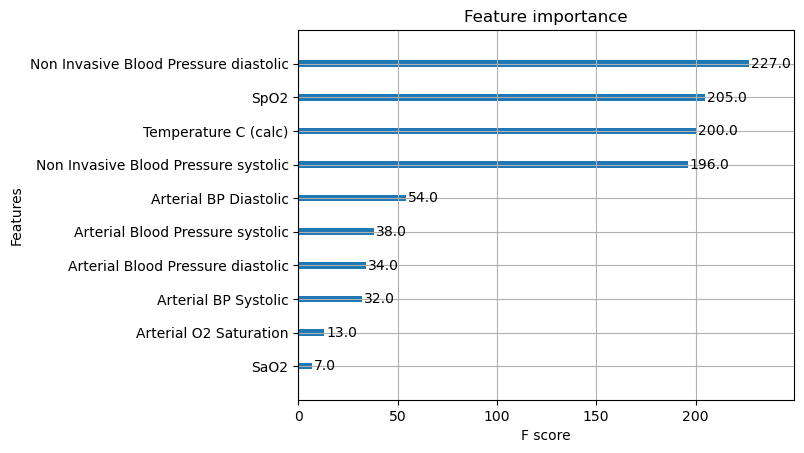

In [32]:
plot_importance(xgb_model, max_num_features=10)
plt.show()

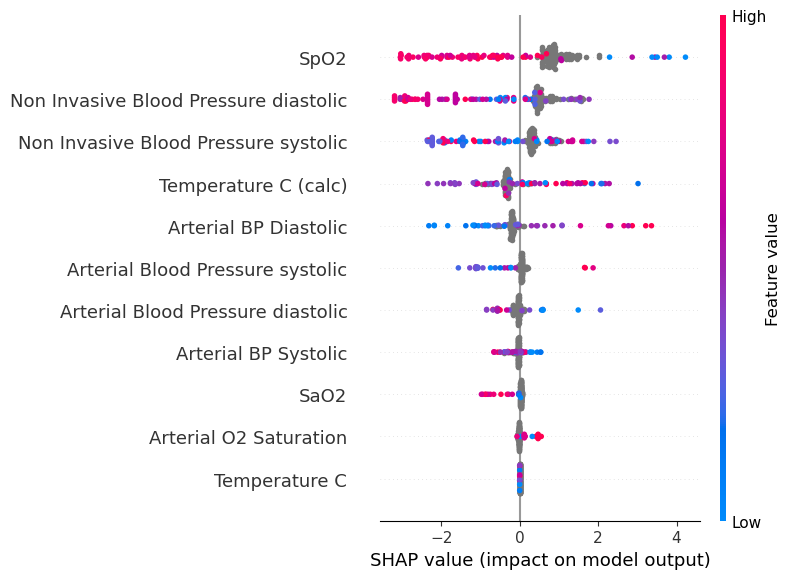

In [33]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_xgb)
shap.summary_plot(shap_values, X_test_xgb)

________________

In [34]:
'''
# Agrupar por subject_id e janela de tempo, calculando a média das medições
merged_data['time_window'] = merged_data['charttime'].dt.floor('6h')

# Pivotar: Cada itemid vira uma coluna separada
df_pivotado = merged_data.pivot_table(
    index=['subject_id', 'time_window'], 
    columns='itemid', 
    values='value',
    aggfunc='mean'
)

# Adicionar prefixo 'itemid_' nas colunas para fácil identificação
df_pivotado.columns = [f'itemid_{int(col)}' for col in df_pivotado.columns]

# Resetar o índice para organizar a tabela final
#df_pivotado = df_pivotado.reset_index()

#df_pivotado = df_pivotado.set_index(['subject_id', 'time_window'])

df_pivotado = df_pivotado.rename(columns=sinais_target)

df_pivotado
'''

"\n# Agrupar por subject_id e janela de tempo, calculando a média das medições\nmerged_data['time_window'] = merged_data['charttime'].dt.floor('6h')\n\n# Pivotar: Cada itemid vira uma coluna separada\ndf_pivotado = merged_data.pivot_table(\n    index=['subject_id', 'time_window'], \n    columns='itemid', \n    values='value',\n    aggfunc='mean'\n)\n\n# Adicionar prefixo 'itemid_' nas colunas para fácil identificação\ndf_pivotado.columns = [f'itemid_{int(col)}' for col in df_pivotado.columns]\n\n# Resetar o índice para organizar a tabela final\n#df_pivotado = df_pivotado.reset_index()\n\n#df_pivotado = df_pivotado.set_index(['subject_id', 'time_window'])\n\ndf_pivotado = df_pivotado.rename(columns=sinais_target)\n\ndf_pivotado\n"

In [35]:
from ydata_profiling import ProfileReport
data = df_final.drop(columns='subject_id')
profile = ProfileReport(data, title="Pandas Profiling Report")

In [36]:
#profile.to_notebook_iframe()